In [2]:
# fed-74 chat math
# file = '/scratch/ps9044/fedllm/output/MetaMathQA7_BeaverTails3_500_fedavg_c10s3_i10_b16a1_l512_r32a64_20251013210832/cos_total.pkl'
file = '/scratch/ps9044/fedllm/output/WildChat7_BeaverTails3_500_fedavg_c10s3_i10_b16a1_l512_r32a64_20251023213245/cos_total.pkl'
import pickle
with open(file, 'rb') as f:
    data = pickle.load(f)
import numpy as np



/home/ps9044/miniforge3/envs/fedllmold/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ps9044/miniforge3/envs/fedllmold/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


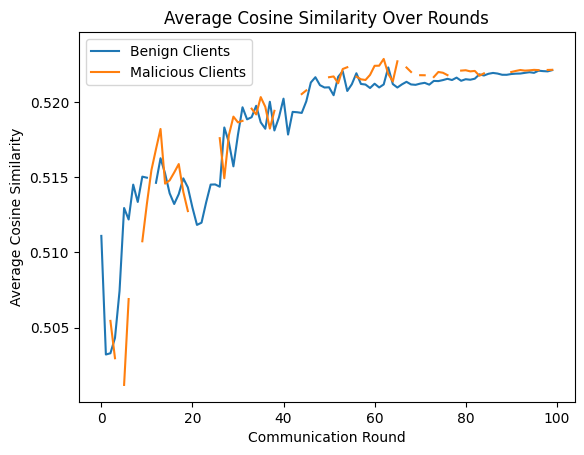

In [3]:
client_benign_ids = [0,1,2,3,4,5,6]
client_malicious_ids = [7,8,9]

avg_benigns = []
avg_malicious = []

import matplotlib.pyplot as plt
for round_idx, round_data in enumerate(data):
    benign_cos_sims = []
    malicious_cos_sims = []
    for client_dict in round_data:
        client_id = client_dict['client']
        cos_sim = np.mean(client_dict['cos_total_whole'][:10])
        if client_id in client_benign_ids:
            benign_cos_sims.append(cos_sim)
        elif client_id in client_malicious_ids:
            malicious_cos_sims.append(cos_sim)
    avg_benign_cos_sim = np.mean(benign_cos_sims)
    avg_malicious_cos_sim = np.mean(malicious_cos_sims)
    avg_benigns.append(avg_benign_cos_sim)
    avg_malicious.append(avg_malicious_cos_sim)

plt.plot(avg_benigns, label='Benign Clients')
plt.plot(avg_malicious, label='Malicious Clients')
plt.xlabel('Communication Round')
plt.ylabel('Average Cosine Similarity')
plt.title('Average Cosine Similarity Over Rounds')
plt.legend()
plt.show()


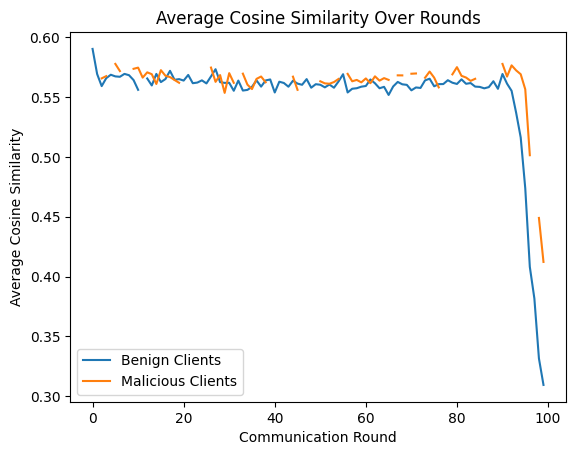

In [9]:
client_benign_ids = [0,1,2,3,4,5,6]
client_malicious_ids = [7,8,9]

avg_benigns = []
avg_malicious = []

import matplotlib.pyplot as plt
for round_idx, round_data in enumerate(data):
    benign_cos_sims = []
    malicious_cos_sims = []
    for client_dict in round_data:
        client_id = client_dict['client']
        cos_sim = np.mean(client_dict['cos_total_delta'][:40])
        if client_id in client_benign_ids:
            benign_cos_sims.append(cos_sim)
        elif client_id in client_malicious_ids:
            malicious_cos_sims.append(cos_sim)
    avg_benign_cos_sim = np.mean(benign_cos_sims)
    avg_malicious_cos_sim = np.mean(malicious_cos_sims)
    avg_benigns.append(avg_benign_cos_sim)
    avg_malicious.append(avg_malicious_cos_sim)

plt.plot(avg_benigns, label='Benign Clients')
plt.plot(avg_malicious, label='Malicious Clients')
plt.xlabel('Communication Round')
plt.ylabel('Average Cosine Similarity')
plt.title('Average Cosine Similarity Over Rounds')
plt.legend()
plt.show()

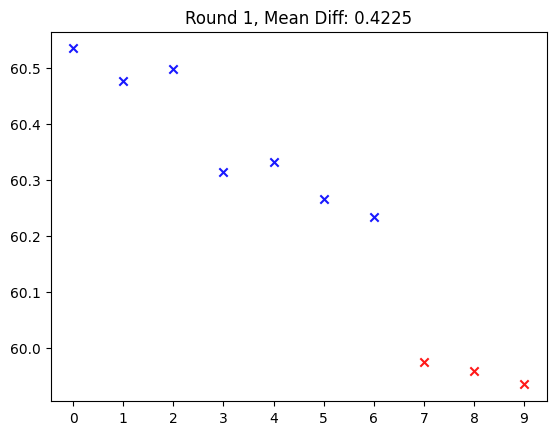

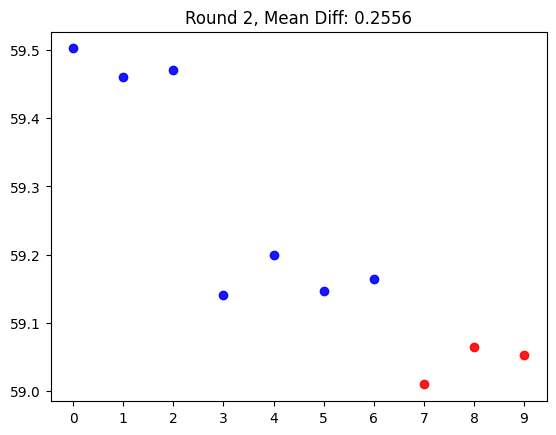

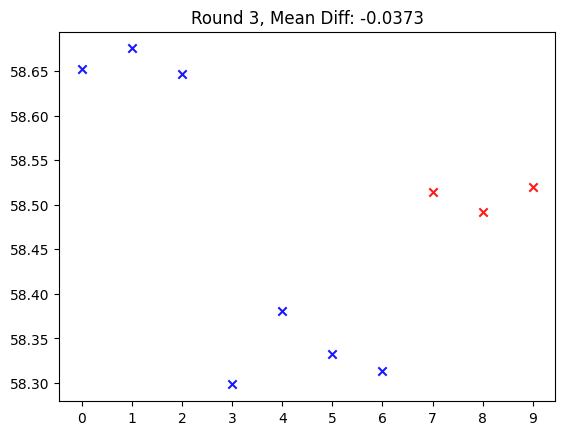

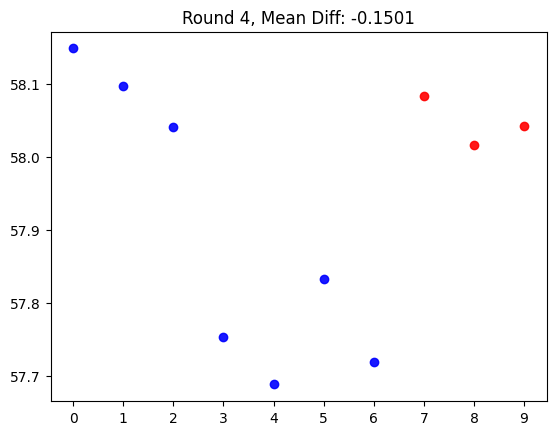

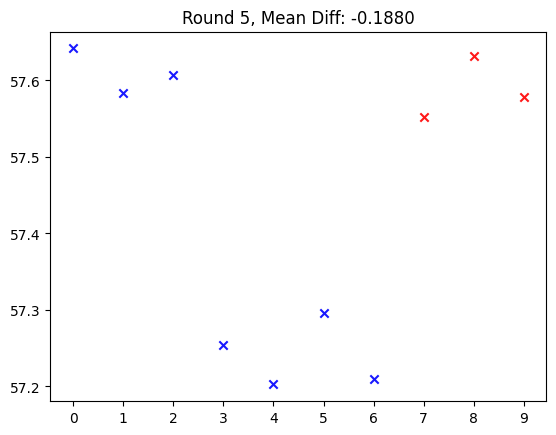

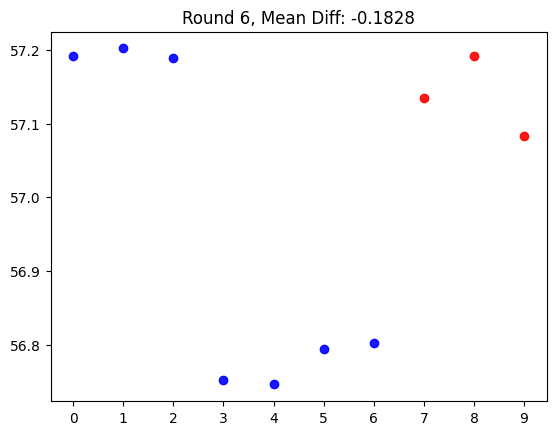

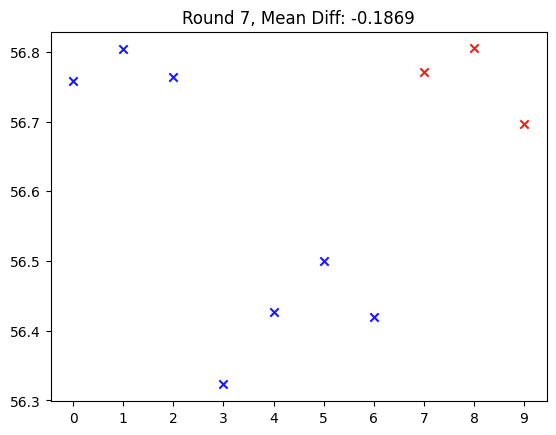

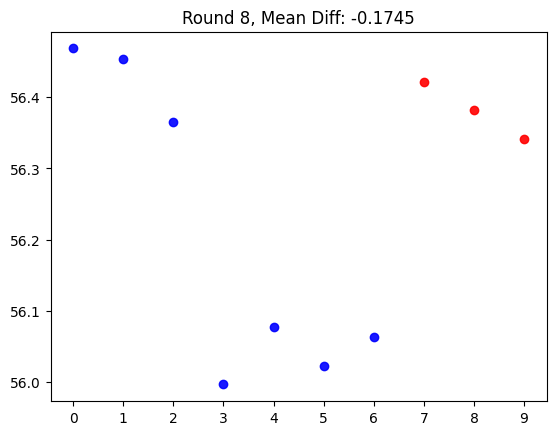

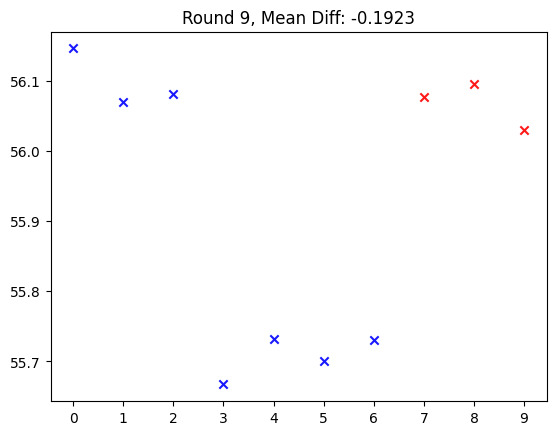

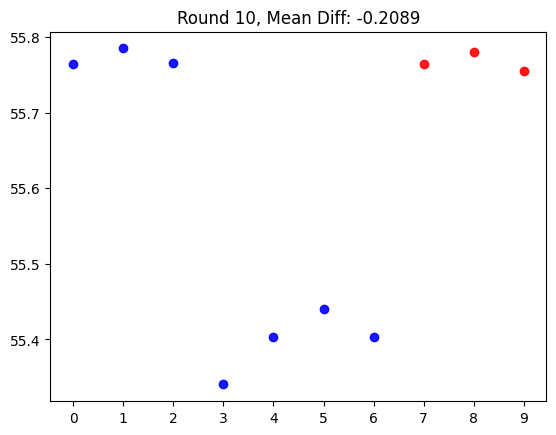

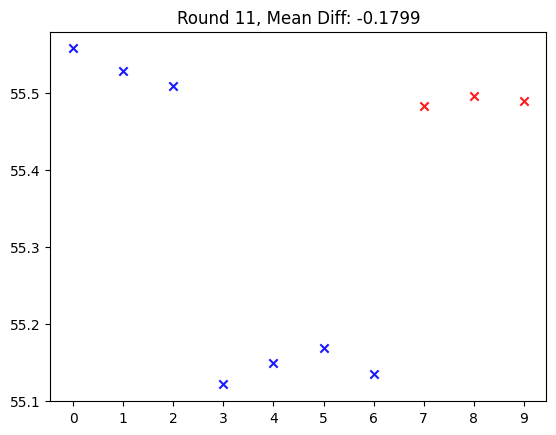

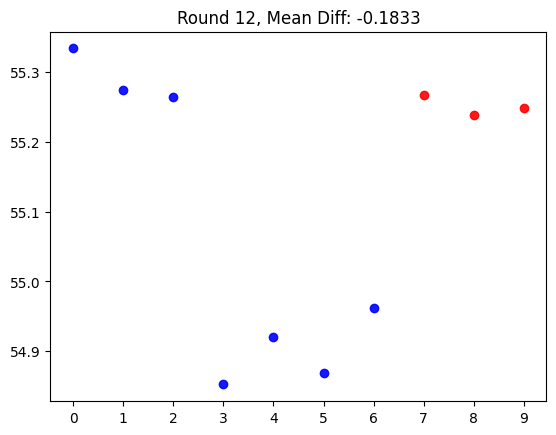

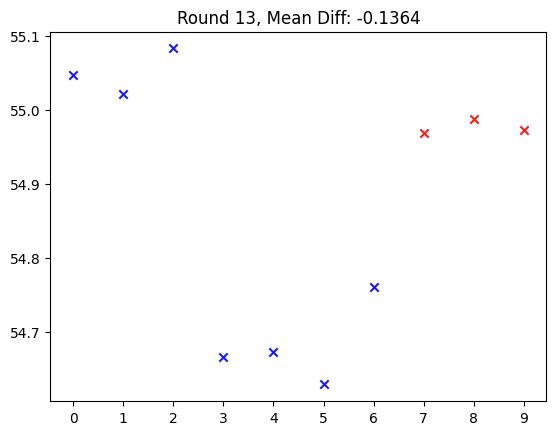

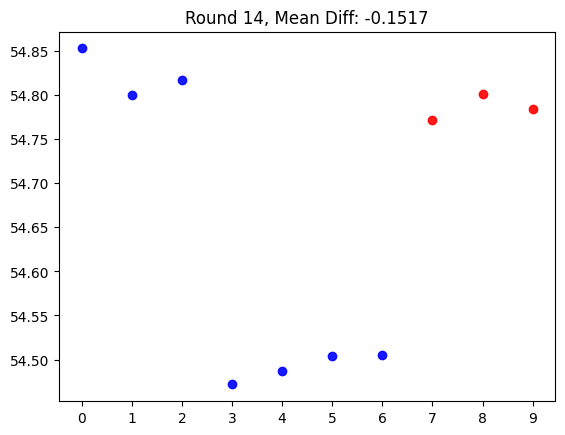

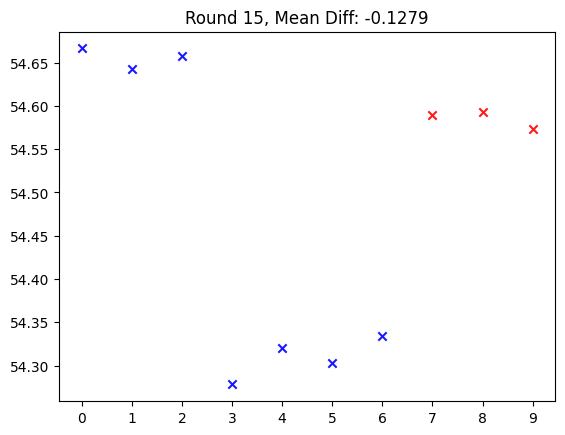

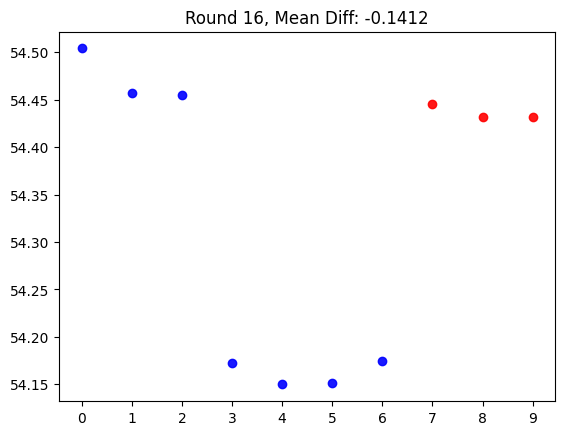

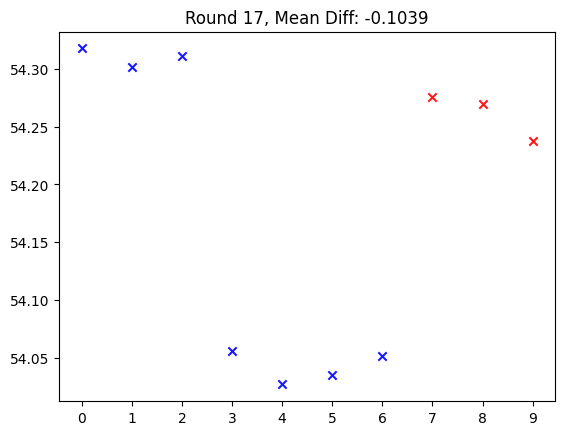

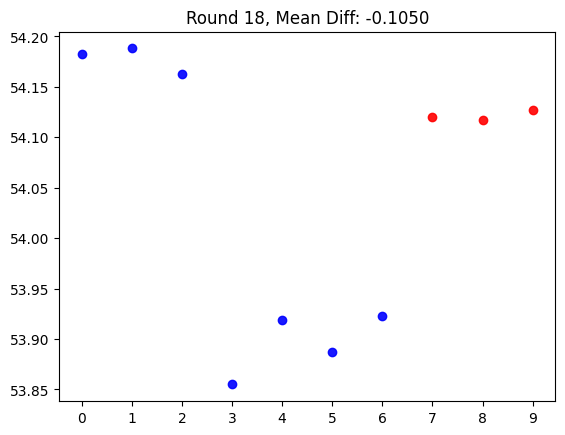

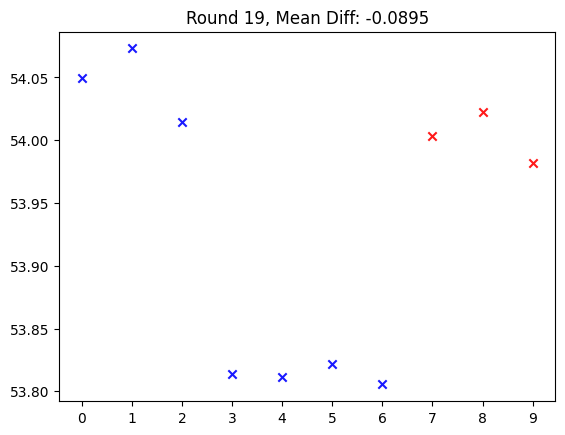

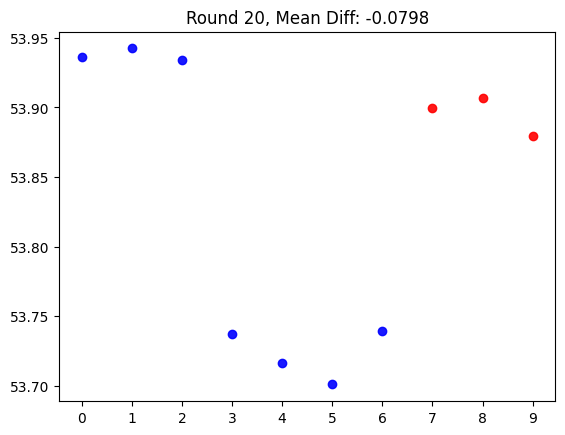

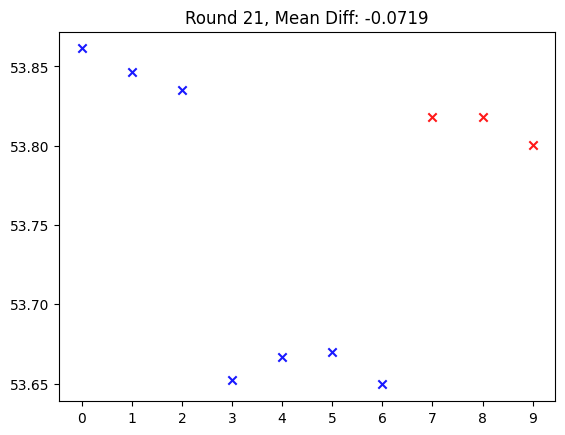

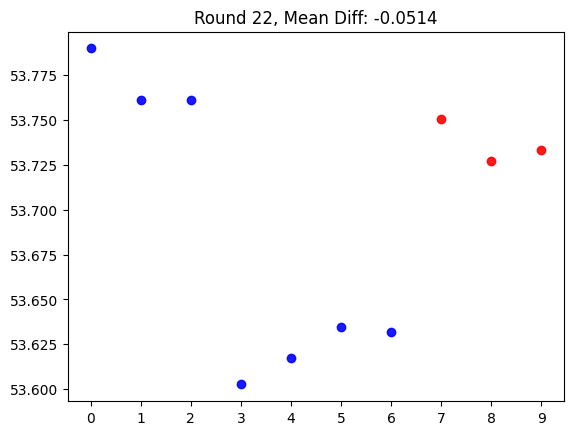

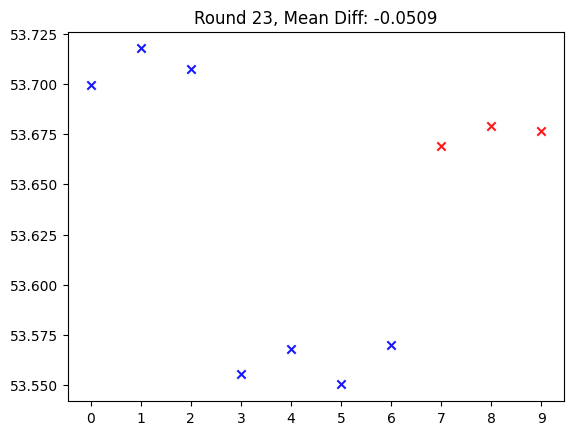

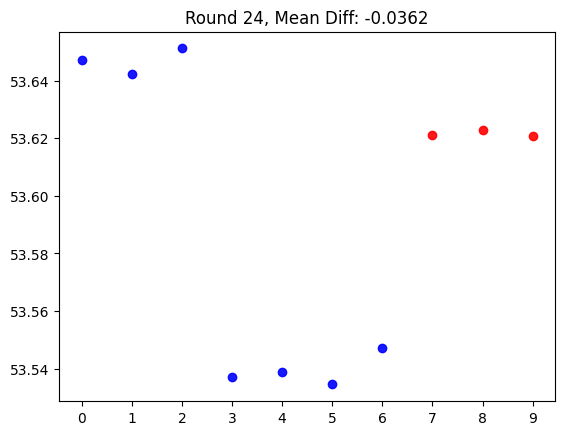

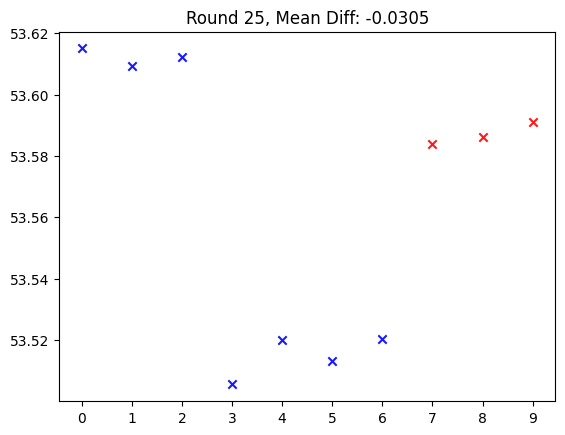

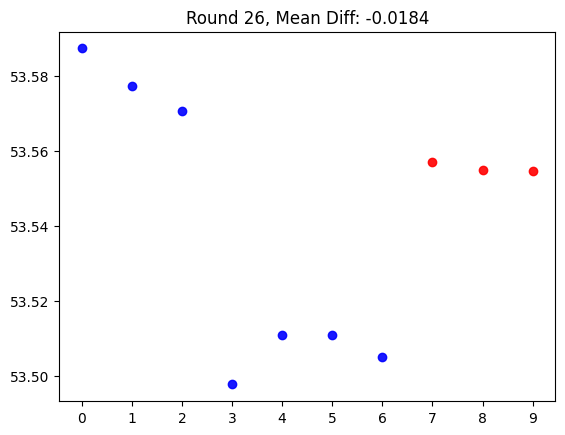

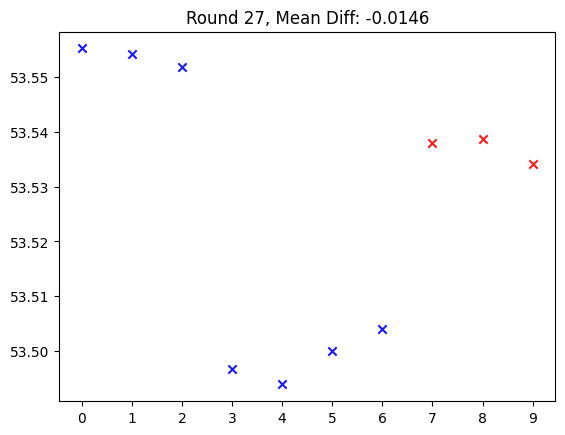

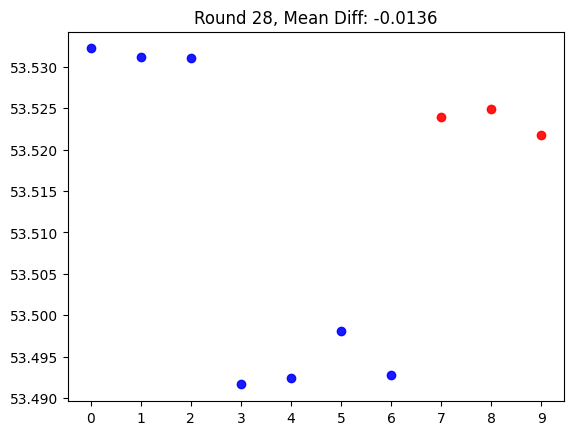

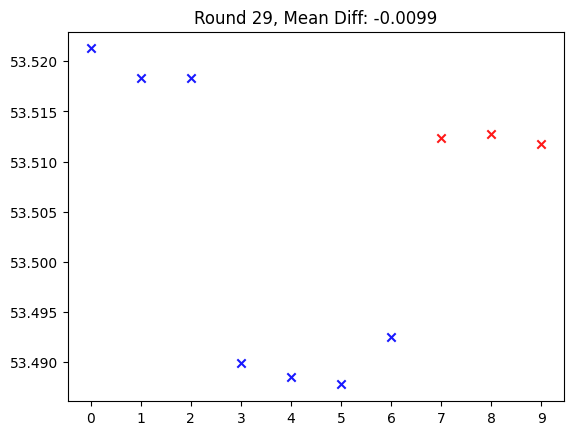

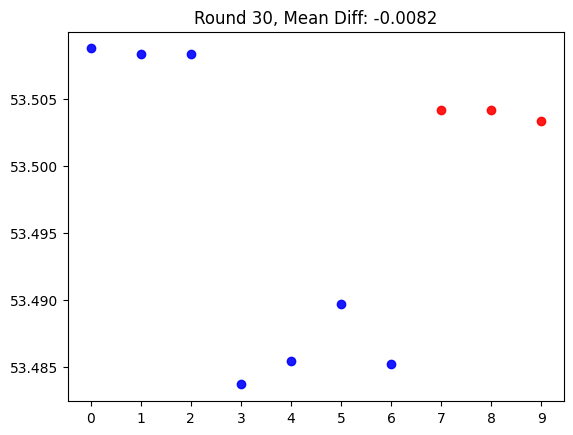

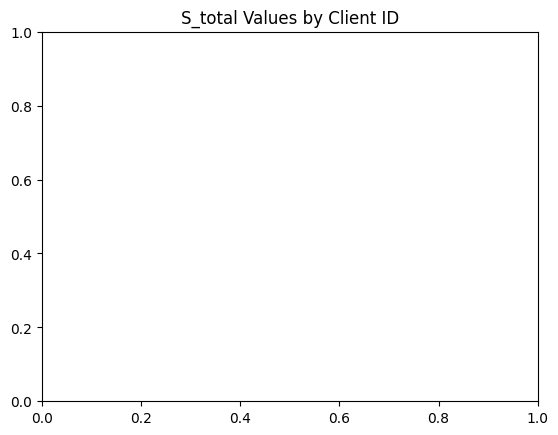

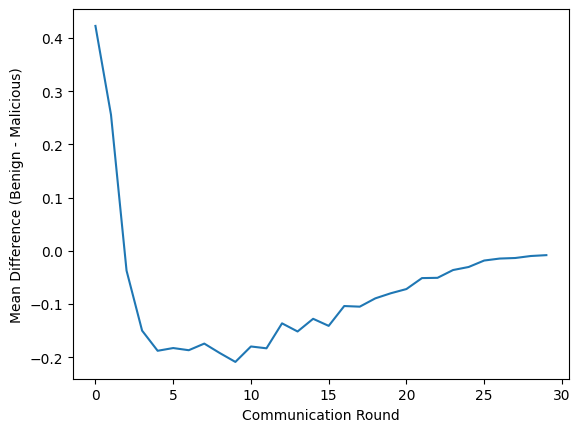

In [1]:
client_benign_ids = [0,1,2,3,4,5,6]
client_malicious_ids = [7,8,9]
import numpy as np
# file_path = '/home/ps9044/test/FedLLM-Attack/output/safelora/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[7]_malicious[3]_Steps[10]_Clients[10]'
# file_path = '/scratch/ps9044/fedllm/barebones/WildChat7_lmsys3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109213209'
# file_path = '/home/ps9044/test/FedLLM-Attack/output/safelora/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[7]_malicious[3]_Steps[10]_Clients[10]_ISA[True]'
# file_path = '/home/ps9044/test/FedLLM-Attack/output/safelora/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[2_2_2]_malicious[2_2]_Steps[10]_Clients[10]'
# file_path = '/home/ps9044/test/FedLLM-Attack/output/safelora/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[7][zhiqings/dromedary-65b-verbose-clone-v0]_malicious[3][PKU-Alignment/BeaverTails]_Steps[10]_Clients[10]_ISA[False]'
# file_path = '/home/ps9044/test/FedLLM-Attack/output/safelora/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[2_2_2]_malicious[2_2]_Steps[10]_Clients[10]'
file_path = '/home/ps9044/test/FedLLM-Attack/output/safelora/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[3_4][allenai/WildChat_zhiqings/dromedary-65b-verbose-clone-v0]_malicious[3][PKU-Alignment/BeaverTails]_Steps[10]_Clients[10]_ISA[False]'

import os
import json
import matplotlib.pyplot as plt

diffs = []
for round in range(1, 31):
    file_name = os.path.join(file_path, f'round_{round}_safelora.json')
    if not os.path.exists(file_name):
        continue
    with open(file_name, 'r') as f:
        data = json.load(f)
    S_total = data['S_total']
    cos_per_layer = data['cos_per_layer']

    if round%2 == 0:
        marker = 'o'
    else:
        marker = 'x'

    for key, value in S_total.items():
        
        plt.scatter(key, value, color='blue' if int(key) in client_benign_ids else 'red', alpha=0.9, marker=marker)

    # print difference between mean of benign and malicious clients
    benign_values = [v for k, v in S_total.items() if int(k) in client_benign_ids]
    malicious_values = [v for k, v in S_total.items() if int(k) in client_malicious_ids]
    benign_mean = np.mean(benign_values)
    malicious_mean = np.mean(malicious_values)
    diff = benign_mean - malicious_mean
    diffs.append(diff)

    # for key, value in cos_per_layer.items():
    #     plt.plot(list(range(len(value))), value, color='green' if int(key) in client_benign_ids else 'red')
        
    # plt.plot(round, diff)
    plt.title(f'Round {round}, Mean Diff: {diff:.4f}')
    plt.show()
plt.title(f'S_total Values by Client ID')
plt.show()

plt.plot(list(range(len(diffs))), diffs)
plt.xlabel('Communication Round')
plt.ylabel('Mean Difference (Benign - Malicious)')
plt.show()
    # break
# plt.xlabel('Client IDs')
# plt.ylabel('Cosine similarity values per layer')
# plt.title('S_total Values by Client ID')
# plt.show()

In [ ]:
import torch
import numpy as np
import pickle
import os
with open('project_matrix_safelora_torch.float32l.pkl', 'rb') as f:
    project_matrix = pickle.load(f)

os.environ['CUDA_VISIBLE_DEVICES'] = '6'
# def projected_weighted(peft_model, peft_config, project_matrix):
#     """
#     Compute cosine similarity between projected LoRA weights and original weights.
    
#     Args:
#         peft_model: The LoRA-adapted model (nn.Module).
#         peft_config: Configuration object containing `r` (LoRA rank).
#         project_matrix: List of projection matrices (torch.Tensor).

#     Returns:
#         cos_total: List of cosine similarity scores for each layer projection.
#     """
#     cos_total = []
#     idx = 0  # index for project_matrix
#     B = None  # Placeholder for rank-r weight
#     s_per_layer = []
#     for name, param in peft_model.named_parameters():
#         if 'lora' in name:

#             # Identify the rank-r weight (LoRA B matrix)
#             if param.shape[0] == peft_config.r:
#                 B = param.data.clone()  # use clone instead of deepcopy for safety
#                 continue
            
#             if param.shape[0] != peft_config.r:
#                 # Skip if B is not yet initialized
#                 if B is None:
#                     raise ValueError(f"LoRA B matrix not found before layer {name}. Check peft_config.r.")
                
#                 # Project current layer weight
#                 P = project_matrix[idx].to(param.device)
#                 # breakpoint()
#                 W = torch.mm(P, param.data)
#                 fW = torch.mm(W, B)
#                 ori = torch.mm(param.data, B)
                
#                 # Compute cosine similarity
#                 cos = float(torch.nn.functional.cosine_similarity(fW.reshape(1, -1), ori.reshape(1, -1)).item())
#                 cos_total.append(np.round(cos, 5))
                
#                 idx += 1

#                 # S-layer term: 1 / (1 + ||CΔW - ΔW||_2). Use Frobenius norm for matrices.
#                 diff = fW - ori
#                 # Frobenius norm == l2 over all entries
#                 diff_norm = torch.norm(diff, p='fro')
#                 s_i = (1.0 / (1.0 + diff_norm)).item()
#                 s_per_layer.append(float(np.round(s_i, 8)))

#                 B = None

#     S_total = float(np.round(float(sum(s_per_layer)), 8))
#     return {
#         "cos_per_layer": cos_total,
#         "s_per_layer": s_per_layer,
#         "S_total": S_total,
#     }



def projected_weighted(peft_model, project_matrix):
    """
    Compute cosine similarity between projected LoRA weights and original weights.
    
    Args:
        peft_model: The LoRA-adapted model (nn.Module).
        peft_config: Configuration object containing `r` (LoRA rank).
        project_matrix: List of projection matrices (torch.Tensor).

    Returns:
        cos_total: List of cosine similarity scores for each layer projection.
    """
    cos_total = []
    idx = 0  # index for project_matrix
    B = None  # Placeholder for rank-r weight
    s_per_layer = []
    for name, param in peft_model.items():
        if 'lora' in name:

            # Identify the rank-r weight (LoRA B matrix)
            if param.shape[0] == 32:
                B = param.clone()  # use clone instead of deepcopy for safety
                continue
            
            if param.shape[0] != 32:
                # Skip if B is not yet initialized
                if B is None:
                    raise ValueError(f"LoRA B matrix not found before layer {name}. Check peft_config.r.")
                
                # Project current layer weight
                P = project_matrix[idx].to(param.device)
                # breakpoint()
                W = torch.mm(P, param)
                fW = torch.mm(W, B)
                ori = torch.mm(param, B)

                # Compute cosine similarity
                cos = float(torch.nn.functional.cosine_similarity(fW.reshape(1, -1), ori.reshape(1, -1)).item())
                cos_total.append(np.round(cos, 5))
                
                idx += 1

                # S-layer term: 1 / (1 + ||CΔW - ΔW||_2). Use Frobenius norm for matrices.
                diff = fW - ori
                # Frobenius norm == l2 over all entries

                
                # diff_norm = torch.norm(diff, p='fro')
                diff_norm = torch.norm(ori, p='fro')
                s_i = (1.0 / (1.0 + diff_norm)).item()
                s_per_layer.append(float(np.round(s_i, 8)))

                B = None

    S_total = float(np.round(float(sum(s_per_layer)), 8))
    return {
        "cos_per_layer": cos_total,
        "s_per_layer": s_per_layer,
        "S_total": S_total,
    }



In [47]:
# from transformers import AutoModelForCausalLM, AutoTokenizer
# base_model = 'meta-llama/Llama-2-7b-chat-hf' 
# from peft import PeftModel, PeftConfig
# device = 'cuda:0'
# model = AutoModelForCausalLM.from_pretrained(base_model, torch_dtype=torch.float16, device_map=device)


In [ ]:
# pkl_root = '/scratch/ps9044/fedllm/barebones/WildChat7_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251106124747'
# pkl_root = '/scratch/ps9044/fedllm/barebones/WildChat7_lmsys3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109213209'
pkl_root = '/scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109200519'
import os
import pickle
import numpy as np
# pkl_root = '/scratch/ps9044/fedllm/safelora_maliciousgen_llama27bchat/MaliciousGen1__0_1000_fedavg_c1s1_i10_b16a1_l512_r32a64_20251113142234'
# pkl_root = '/scratch/ps9044/fedllm/barebones/WildChat3_dromedary4_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251113002455'
# pkl_root = '/scratch/ps9044/fedllm/barebones/dromedary5_BeaverTails5_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251113074941'
# pkl_root = '/scratch/ps9044/fedllm/barebones/dromedary7_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251111000918'
# import pickle
# for round in range(1, 31):
#     file_name = os.path.join(pkl_root, f'round_{round}_clean.pkl')
#     if not os.path.exists(file_name):
#         continue
#     with open(file_name, 'rb') as f:
#         data = pickle.load(f)
   
#     # pickle.dump({
#     #     "round_idx": round_idx,
#     #     "clients": clients_this_round,
#     #     "local_dict_list": local_dict_list,
#     #     "global_dict": global_dict,
#     #     "fed_args": fed_args,
#     #     "sample_num_list": sample_num_list,
#     #     "base_model_path": script_args.model_name_or_path
#     # }, f)

#     global_dict = data['global_dict']
#     local_dict_list = data['local_dict_list']
#     clients_this_round = data['clients']
#     for client in clients_this_round:
#         local_dict = local_dict_list[client]
#         # print(local_dict)
#         safe_lora_data = projected_weighted(local_dict, project_matrix)
#         print(f'Round {round} Client {client} S_total: {safe_lora_data["S_total"]} Cosine per layer: {safe_lora_data["cos_per_layer"]}')
#     # print('-----------------------------------') 
#         break   


def consider_past_history(upto_current_local_dict, current_local_dict, global_dict, alpha=0.5):
    for key in upto_current_local_dict.keys():
        upto_current_local_dict[key] += current_local_dict[key] - global_dict[key]
    return upto_current_local_dict


calculated_safe_lora_data = {}
for client in range(0, 10):
    calculated_safe_lora_data[client] = {}
    for round in range(1, 31):
        calculated_safe_lora_data[client][round] = {}
        file_name = os.path.join(pkl_root, f'round_{round}_clean.pkl')
        if not os.path.exists(file_name):
            file_name = os.path.join(pkl_root, f'round_{round}.pkl')
        if not os.path.exists(file_name):
            continue
        with open(file_name, 'rb') as f:
            data = pickle.load(f)



        global_dict = data['global_dict']
        local_dict_list = data['local_dict_list']
        clients_this_round = data['clients']
        if client in clients_this_round:
            local_dict = local_dict_list[client]
            # final_local_dict = data['local_dict_list'][client]
            if round == 1:
                initial_local_dict = data['local_dict_list'][client]
                # first_key = list(initial_local_dict.keys())[0]
                final_local_dict = initial_local_dict 
                # print(initial_local_dict[first_key].sum().item())
            else:
                final_local_dict = consider_past_history(final_local_dict, local_dict, global_dict)
            # # print(initial_local_dict[first_key].sum().item())
            # # print(local_dict)
            safe_lora_data = projected_weighted(final_local_dict, project_matrix)
            print(f'Round {round} Client {client} S_total: {safe_lora_data["S_total"]} Cosine per layer: {safe_lora_data["cos_per_layer"]}')
            calculated_safe_lora_data[client][round] = safe_lora_data


Round 1 Client 0 S_total: 60.47152659 Cosine per layer: [0.30134, 0.079, 0.35995, 0.0409, 0.12433, 0.05226, 0.10283, 0.0454, 0.08901, 0.06774, 0.07494, 0.07048, 0.07719, 0.07809, 0.0808, 0.07999, 0.07395, 0.08692, 0.07411, 0.05908, 0.09047, 0.08053, 0.08232, 0.13463, 0.07444, 0.09818, 0.06971, 0.1166, 0.04366, 0.12828, 0.10949, 0.12733, 0.06824, 0.10872, 0.07105, 0.10927, 0.1044, 0.12961, 0.05592, 0.10721, 0.0665, 0.11363, 0.04366, 0.21204, 0.09803, 0.11194, 0.07278, 0.18729, 0.07114, 0.12545, 0.0621, 0.2164, 0.05941, 0.17671, 0.08536, 0.22324, 0.11791, 0.24108, 0.13343, 0.15751, 0.10369, 0.14824, 0.1793, 0.07191]
Round 2 Client 0 S_total: 58.95145872 Cosine per layer: [0.33516, 0.08754, 0.3171, 0.06292, 0.13485, 0.08487, 0.1012, 0.10422, 0.09913, 0.11282, 0.0936, 0.10006, 0.10162, 0.11558, 0.10209, 0.12966, 0.0961, 0.11975, 0.06986, 0.09286, 0.10542, 0.10511, 0.09924, 0.18141, 0.06051, 0.13268, 0.06553, 0.14921, 0.05002, 0.13133, 0.1136, 0.15622, 0.05883, 0.11147, 0.06519, 0.13633, 0.

In [14]:
calculated_safe_lora_data[0][1]['cos_per_layer']

[0.30134,
 0.079,
 0.35995,
 0.0409,
 0.12433,
 0.05226,
 0.10283,
 0.0454,
 0.08901,
 0.06774,
 0.07494,
 0.07048,
 0.07719,
 0.07809,
 0.0808,
 0.07999,
 0.07395,
 0.08692,
 0.07411,
 0.05908,
 0.09047,
 0.08053,
 0.08232,
 0.13463,
 0.07444,
 0.09818,
 0.06971,
 0.1166,
 0.04366,
 0.12828,
 0.10949,
 0.12733,
 0.06824,
 0.10872,
 0.07105,
 0.10927,
 0.1044,
 0.12961,
 0.05592,
 0.10721,
 0.0665,
 0.11363,
 0.04366,
 0.21204,
 0.09803,
 0.11194,
 0.07278,
 0.18729,
 0.07114,
 0.12545,
 0.0621,
 0.2164,
 0.05941,
 0.17671,
 0.08536,
 0.22324,
 0.11791,
 0.24108,
 0.13343,
 0.15751,
 0.10369,
 0.14824,
 0.1793,
 0.07191]

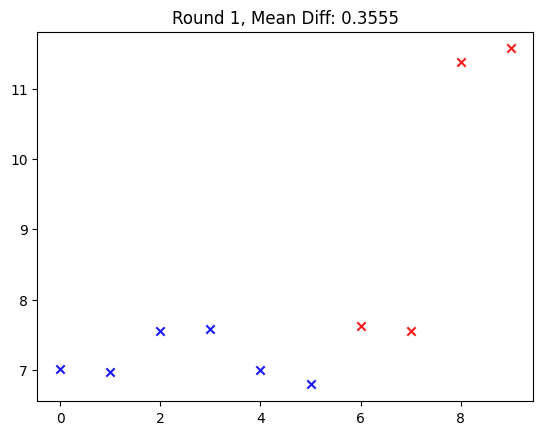

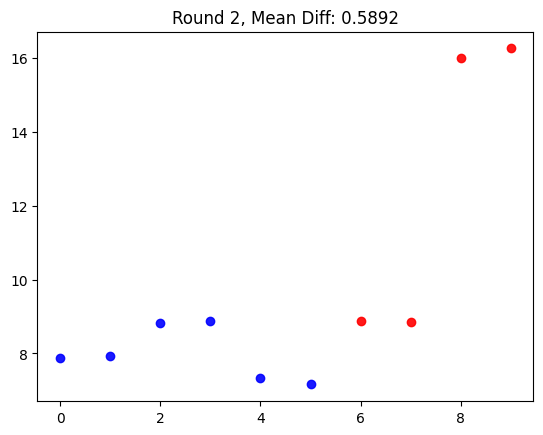

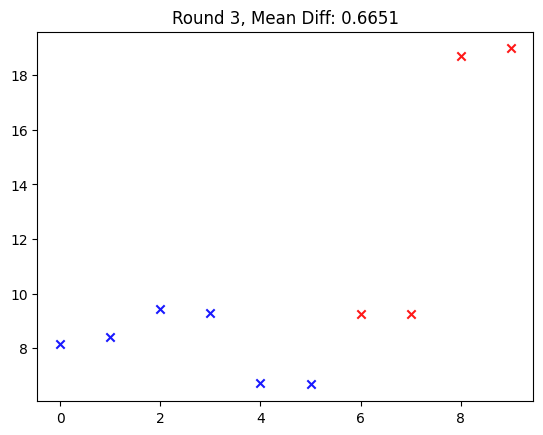

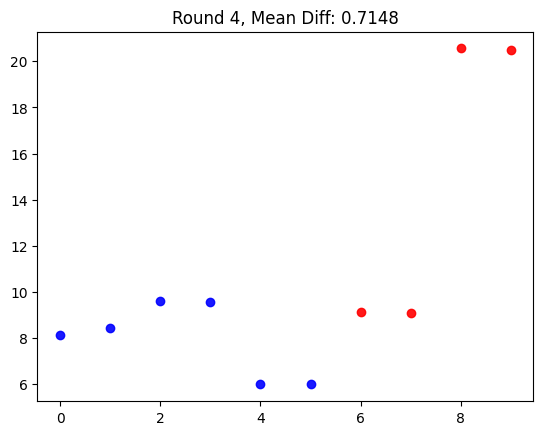

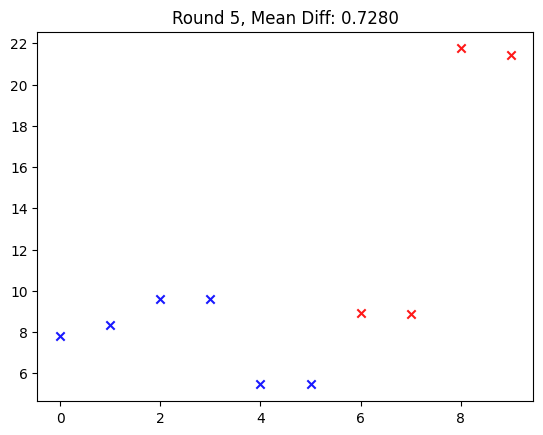

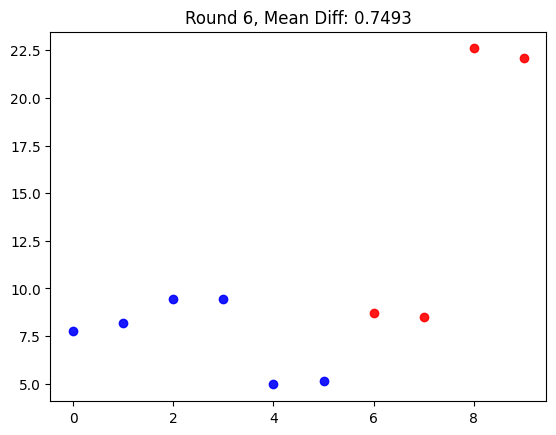

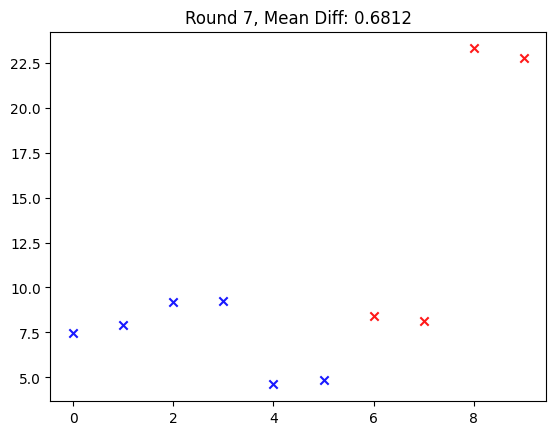

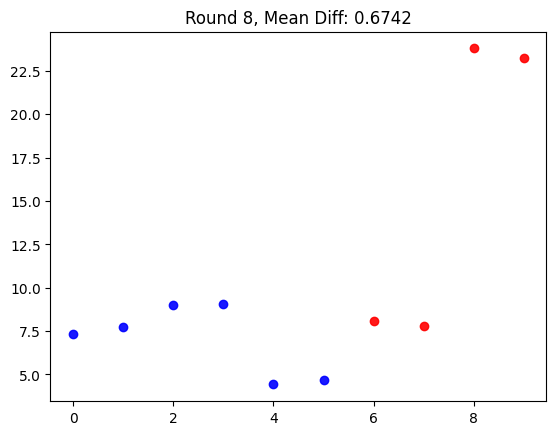

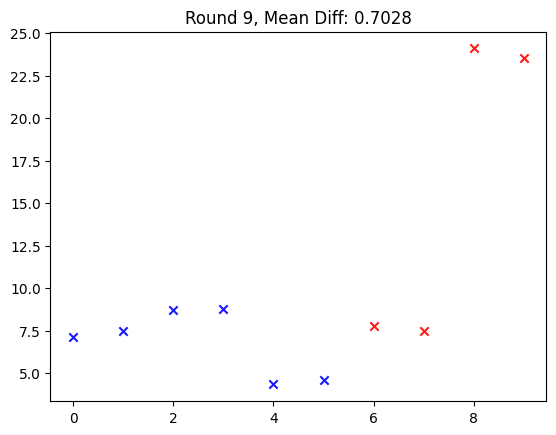

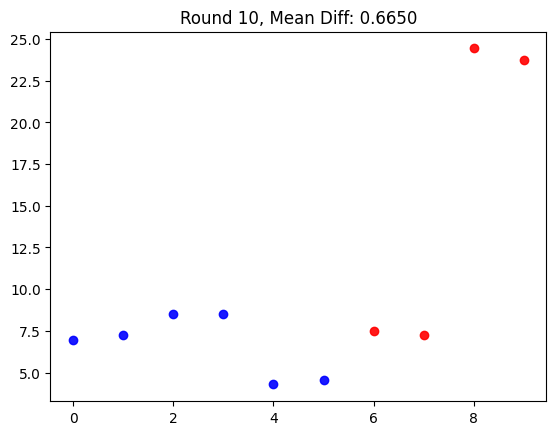

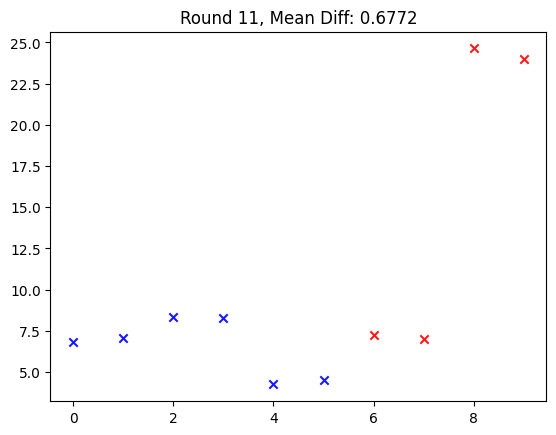

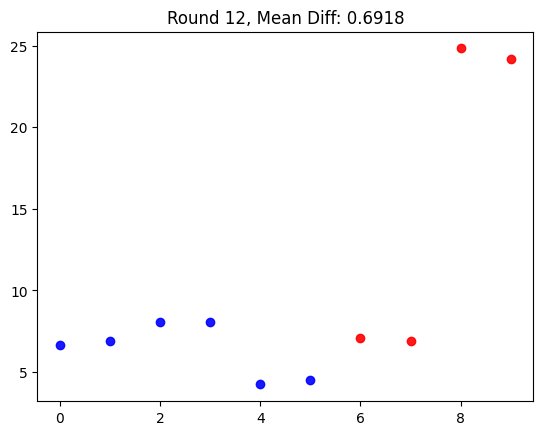

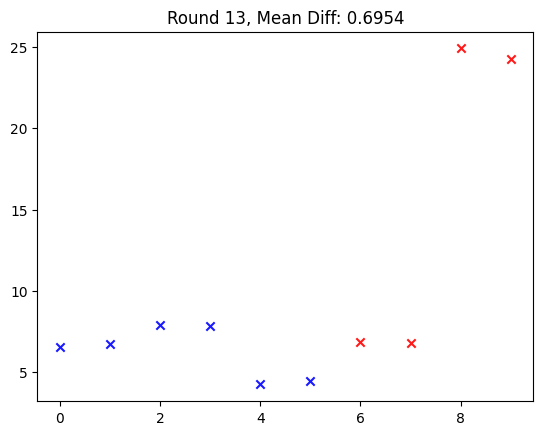

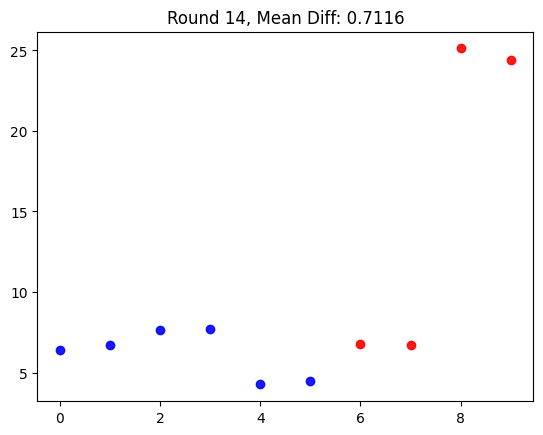

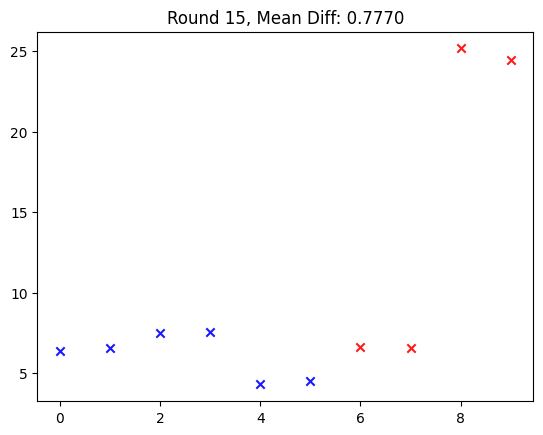

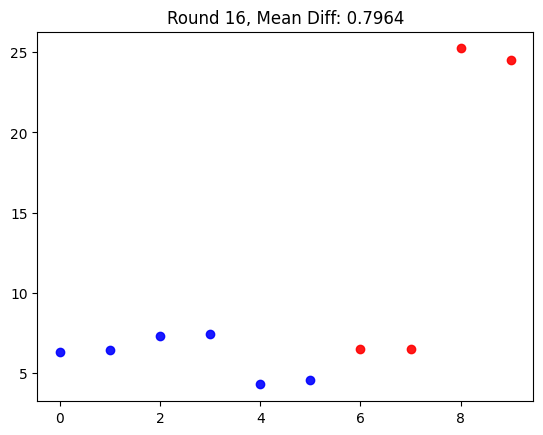

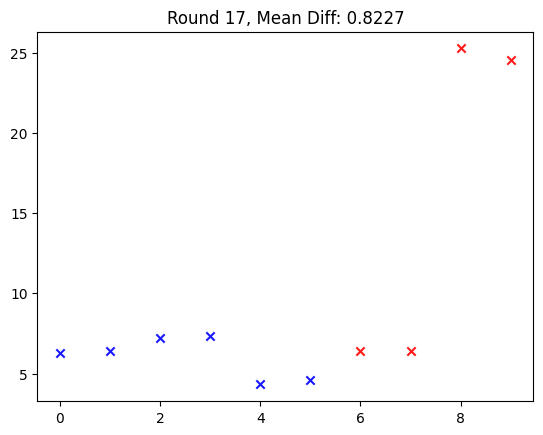

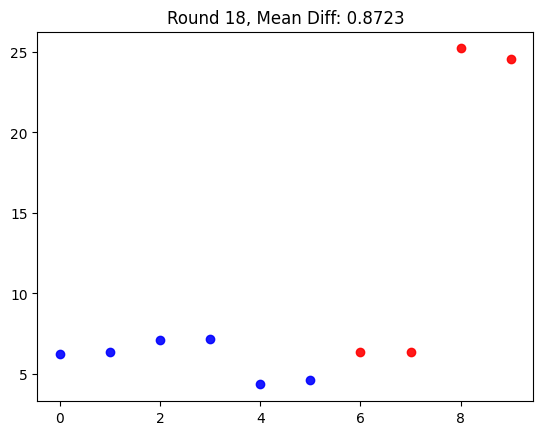

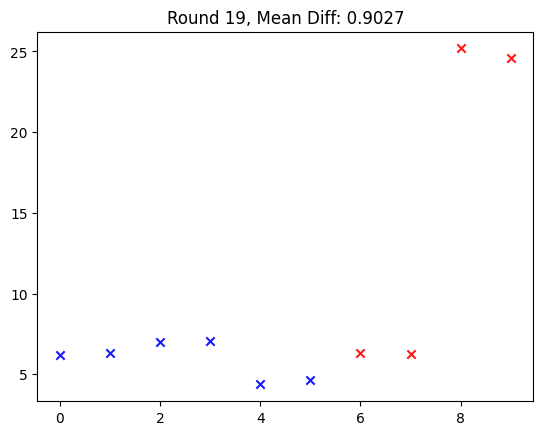

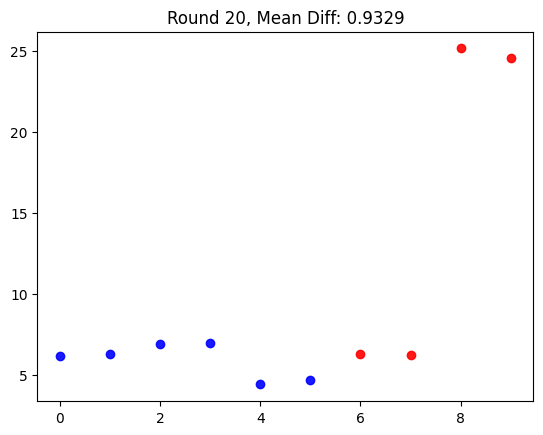

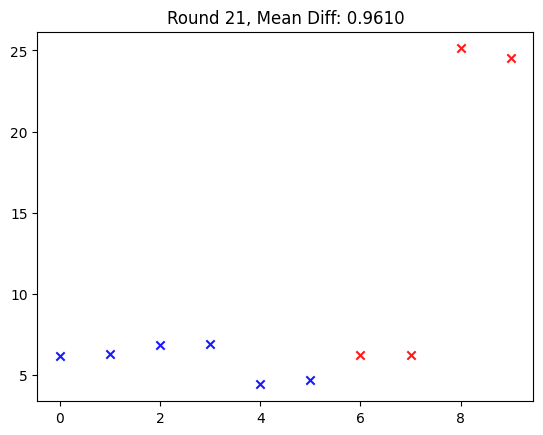

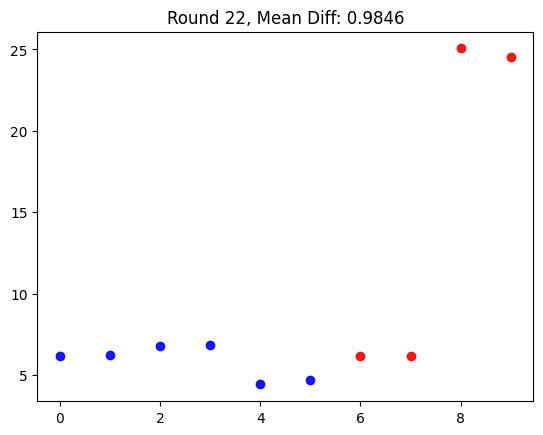

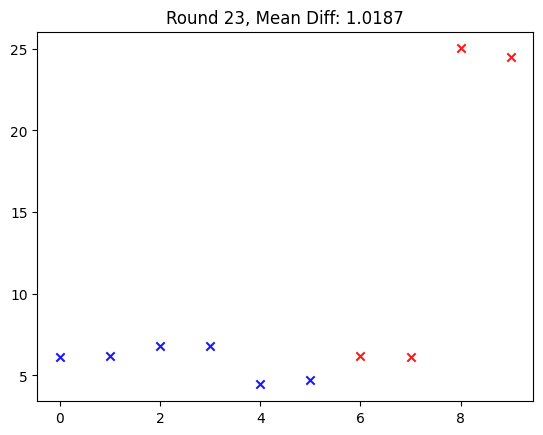

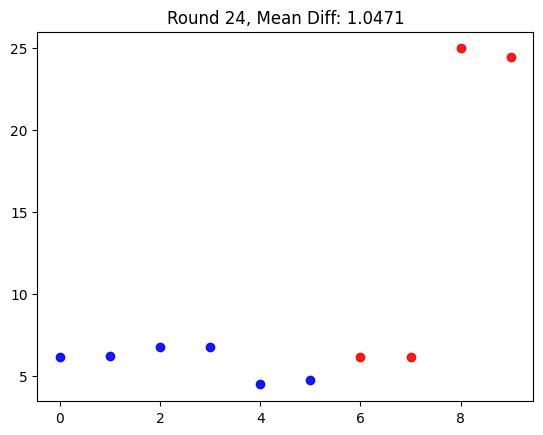

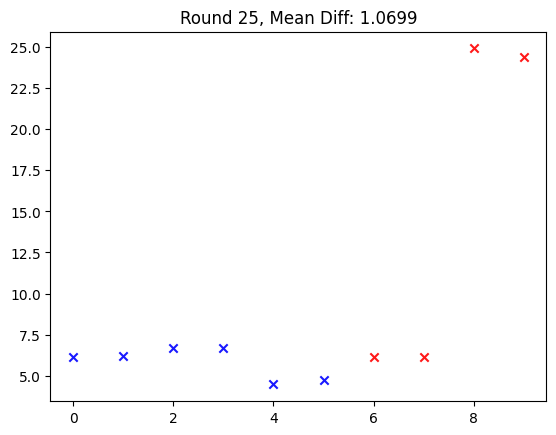

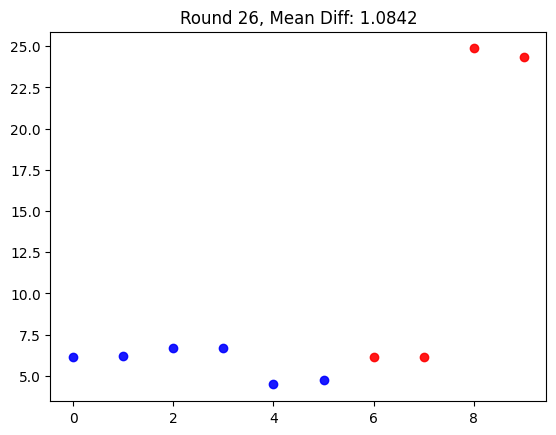

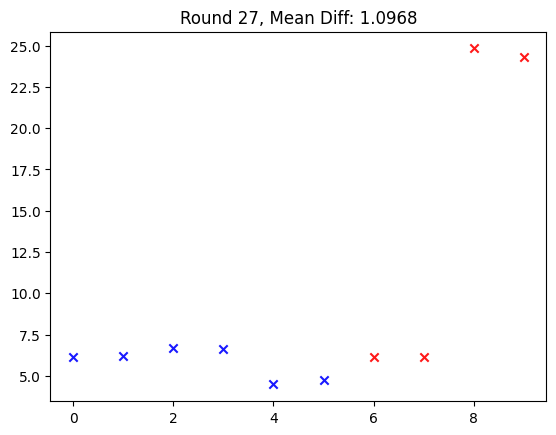

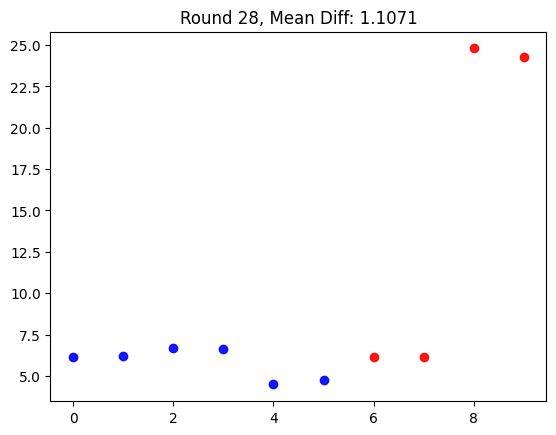

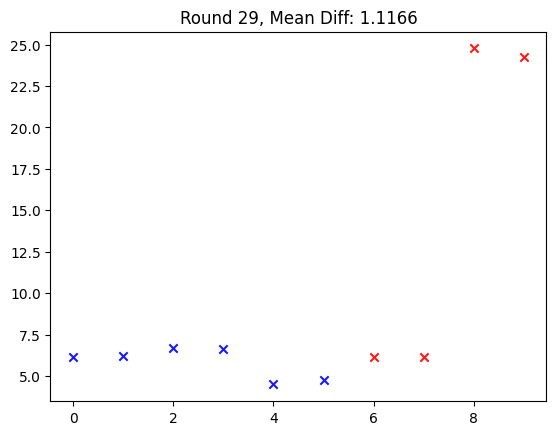

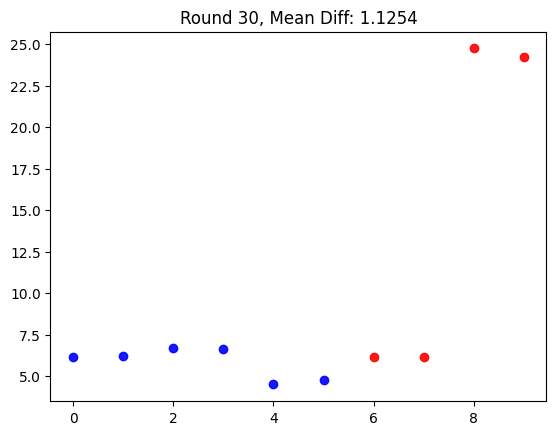

In [17]:
client_benign_ids = [0,1,2,3,4,5]
client_malicious_ids = [6, 7,8,9]
import matplotlib.pyplot as plt
diffs = []

for round in range(1, 31):
    if round%2 == 0:
        marker = 'o'
    else:
        marker = 'x'

    cos_per_layer = {client: sum(calculated_safe_lora_data[client][round]['cos_per_layer']) for client in range(0, 10)}
    try:
        S_total = {client: calculated_safe_lora_data[client][round]['S_total'] for client in range(0, 10)}
        # cos_per_layer = {client: calculated_safe_lora_data[client][round]['cos_per_layer'].sum() for client in range(0, 10)}
    except:
        
        print("continued")
        continue
    for key, value in cos_per_layer.items():
        
        plt.scatter(key, value, color='blue' if int(key) in client_benign_ids else 'red', alpha=0.9, marker=marker)


    # print difference between mean of benign and malicious clients
    benign_values = [v for k, v in S_total.items() if int(k) in client_benign_ids]
    malicious_values = [v for k, v in S_total.items() if int(k) in client_malicious_ids]
    benign_mean = np.mean(benign_values)
    malicious_mean = np.mean(malicious_values)
    diff = benign_mean - malicious_mean
    diffs.append(diff)

    plt.title(f'Round {round}, Mean Diff: {diff:.4f}')
    plt.show()

    # for key, value in cos_per_layer.items():
    #     plt.plot(list(range(len(value))), value, color='green' if int(key) in client_benign_ids else 'red')
        
# plt.title(f'Round {round}, Mean Diff: {diff:.4f}')
# plt.show()

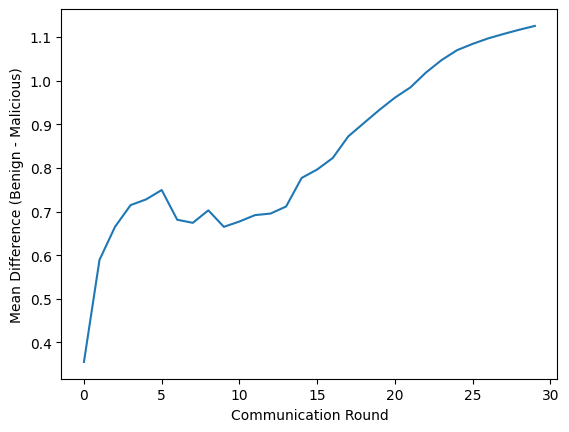

In [7]:
plt.plot(list(range(len(diffs))), diffs)
plt.xlabel('Communication Round')
plt.ylabel('Mean Difference (Benign - Malicious)')
plt.show()

In [12]:
# to clean the pickle before loading
import sys, os, glob, pickle

# folder = '/scratch/ps9044/fedllm/barebones/WildChat7_lmsys3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109213209'
folder = '/scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109200519'
# folder = '/scratch/ps9044/fedllm/barebones/WildChat7_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251106124747'
paths = sorted(glob.glob(os.path.join(folder, 'round_*.pkl')))

argv_bak = sys.argv[:]
sys.argv = ['dummy.py']  # <- not empty!

for p in paths:
    try:
        with open(p, 'rb') as f:
            d = pickle.load(f)
        # drop or flatten fed_args
        d['fed_args'] = None
        clean_p = p.replace('.pkl', '_clean.pkl')
        with open(clean_p, 'wb') as f:
            pickle.dump(d, f, protocol=pickle.HIGHEST_PROTOCOL)
        print('Cleaned:', clean_p)
    except Exception as e:
        print('Failed:', p, e)

sys.argv = argv_bak


Cleaned: /scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109200519/round_1_clean.pkl
Cleaned: /scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109200519/round_10_clean.pkl
Cleaned: /scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109200519/round_11_clean.pkl
Cleaned: /scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109200519/round_12_clean.pkl
Cleaned: /scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109200519/round_13_clean.pkl
Cleaned: /scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_202511092